In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Loading dataset
try:
    df = pd.read_csv('/content/loan_prediction.csv')
    print("Dataset loaded successfully!")
    print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")
    print("--- Column Names & Data Types ---")
    print(df.dtypes)
    print("\n--- First 5 Rows ---")
    print(df.head())
except FileNotFoundError:
    print("Error: Could not find the CSV file. Please make sure you uploaded it to the left folder panel and checked the file name!")

Dataset loaded successfully!
Total Rows: 614, Total Columns: 13

--- Column Names & Data Types ---
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

--- First 5 Rows ---
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0 

In [5]:
print("Step 2: Preprocessing data and balancing classes... Please wait.")

# using strip function for hidden column
df.columns = df.columns.str.strip()

# to find the target column
target_col = [col for col in df.columns if 'status' in col.lower() or 'approve' in col.lower()]
if not target_col:
    target_col = df.columns[-1]
else:
    target_col = target_col[0]

df[target_col] = df[target_col].astype(str).str.strip()
# Handle Missing Values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

id_cols = [col for col in df.columns if 'id' in col.lower() or 'index' in col.lower()]
X = df.drop(columns=[target_col] + id_cols)
y = df[target_col]

# Encode Columns into numbers 0 and 1
label_encoders = {}
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str).str.strip())
        label_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

# Split the dataset into an 80% Training Set and a 20% Testing Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features so they sit on the same statistical playing field
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Preprocessing Complete!")
print(f"Features shape for training: {X_train.shape}")
print(f"Class distribution in training labels: {np.bincount(y_train)}")

Step 2: Preprocessing data and balancing classes... Please wait.
Data Preprocessing Complete!
Features shape for training: (491, 11)
Class distribution in training labels: [149 342]


Step 3: Training machine learning models... Please wait.

================ MODEL PERFORMANCE ================
Logistic Regression Accuracy: 77.24%
Random Forest Accuracy:       77.24%

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           N       0.86      0.42      0.56        43
           Y       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



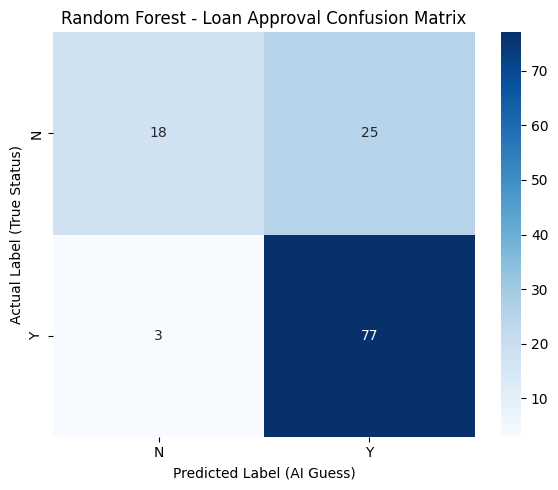

In [6]:
print("Step 3: Training machine learning models... Please wait.")
# Using class_weight='balanced'
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
rf_clf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)

# Train Models on our training data
log_reg.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)

# Make Predictions on the test data
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# Calculate Accuracy Scores
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("\n================ MODEL PERFORMANCE ================")
print(f"Logistic Regression Accuracy: {acc_lr * 100:.2f}%")
print(f"Random Forest Accuracy:       {acc_rf * 100:.2f}%")
print("===================================================\n")

# Evaluation Matrices
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=target_encoder.classes_))

# random forest
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_encoder.classes_,
            yticklabels=target_encoder.classes_)

plt.title('Random Forest - Loan Approval Confusion Matrix')
plt.ylabel('Actual Label (True Status)')
plt.xlabel('Predicted Label (AI Guess)')
plt.tight_layout()
plt.show()